# Train NPE using SimBac with reconstruct trees

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc, run_tarp, check_tarp
from sbi.analysis import sbc_rank_plot
from sbi.analysis import plot_tarp
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load SimBac gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/reconstruct_3/final_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                 _______________________________________ 17
  ______________________________|
 |                              |                        _______________ 19
 |                              |_______________________|
 |                                                      |_______________ 9
 |
 |                                           ___________________________ 14
 |                                          |
_|                                          |                          , 15
 |                  ________________________|                 _________|
 |                 |                        |                |         |, 5
 |                 |                        |                |         ||
 |                 |                        |________________|          | 24
 |                 |                                         |
 |                 |                                         |         , 27
 |                 |                     

In [3]:
drop_col = range(16, 32)

## Load simulation data

In [4]:
theta1 = np.loadtxt('../data/SimBac/reconstruct_3/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/SimBac/reconstruct_3/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/SimBac/reconstruct_3/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/SimBac/reconstruct_3/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/SimBac/reconstruct_3/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/SimBac/reconstruct_3/x3.csv', delimiter=",")

theta4 = np.loadtxt('../data/SimBac/reconstruct_3/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/SimBac/reconstruct_3/x4.csv', delimiter=",")

theta5 = np.loadtxt('../data/SimBac/reconstruct_3/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/SimBac/reconstruct_3/x5.csv', delimiter=",")

x = np.vstack([x1,  x2,  x3,  x4,  x5])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1, theta2, theta3, theta4, theta5])

print(theta.shape, x.shape)

(50000, 3) (50000, 30)


In [5]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

## NPE

### Create prior to pass range knowledge to NPE

In [6]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [7]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [8]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [9]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500,
    training_batch_size=100,
    learning_rate=0.0001,
    stop_after_epochs=20,
    clip_max_norm=None
)
posterior = inference.build_posterior(density_estimator)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [8, 9, 12, 13, 20, 22, 23, 25, 26, 27, 28] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 107 epochs.

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\potentials\posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


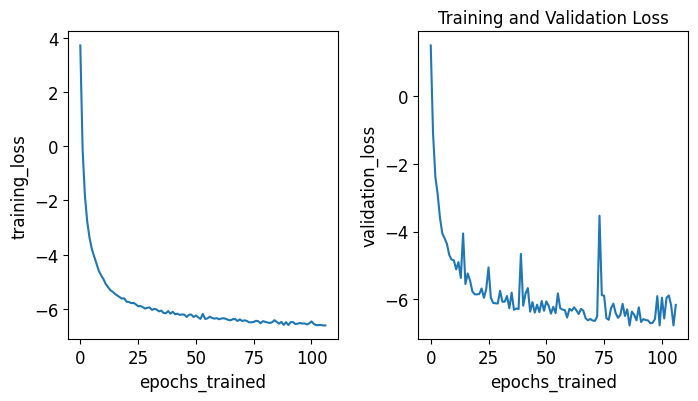

In [10]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Save the trained NPE

In [11]:
save_path = "../data/SimBac/reconstruct_3/trained_npe_posterior.pt"

torch.save(
    {
        "posterior": posterior,
        "sbi_version": sbi.__version__,
        "seed": seed,
        "learning_rate": 0.0001,
        "max_num_epochs": 500,
    },
    save_path,
)

In [12]:
# checkpoint = torch.load(save_path, map_location="cpu")
# posterior = checkpoint["posterior"]